In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples
from mpl_toolkits import mplot3d
from sklearn.model_selection import ParameterGrid
import warnings
warnings.filterwarnings("ignore")

random_state = 42

In [2]:
X_url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/00292/Wholesale%20customers%20data.csv'
delimiter = ','
X0 = pd.read_csv(X_url, delimiter=delimiter)
X0.shape

(440, 8)

In [3]:
X0.head()

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,3,12669,9656,7561,214,2674,1338
1,2,3,7057,9810,9568,1762,3293,1776
2,2,3,6353,8808,7684,2405,3516,7844
3,1,3,13265,1196,4221,6404,507,1788
4,2,3,22615,5410,7198,3915,1777,5185


In [4]:
from sklearn.preprocessing import PowerTransformer
pt = PowerTransformer()
X0_no_nominal = X0.iloc[:, 2:]  # remove Channel and Region columns
X_pt = pd.DataFrame(pt.fit_transform(X0_no_nominal), columns=X0_no_nominal.columns)
X_transformed = pd.concat([X0.iloc[:, :2], X_pt], axis=1)
from sklearn.preprocessing import MinMaxScaler
mms = MinMaxScaler()
X = pd.DataFrame(mms.fit_transform(X_transformed), columns=X_transformed.columns)
X.head()


,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,1.0,1.0,0.501828,0.667606,0.625238,0.208640,0.649941,0.412016
1,1.0,1.0,0.414266,0.670028,0.655690,0.458800,0.674852,0.445663
2,1.0,1.0,0.400077,0.653586,0.627297,0.499856,0.682752,0.654292
3,0.0,1.0,0.509368,0.369264,0.553550,0.636716,0.461095,0.446485
4,1.0,1.0,0.604755,0.580657,0.618985,0.566470,0.601884,0.590255


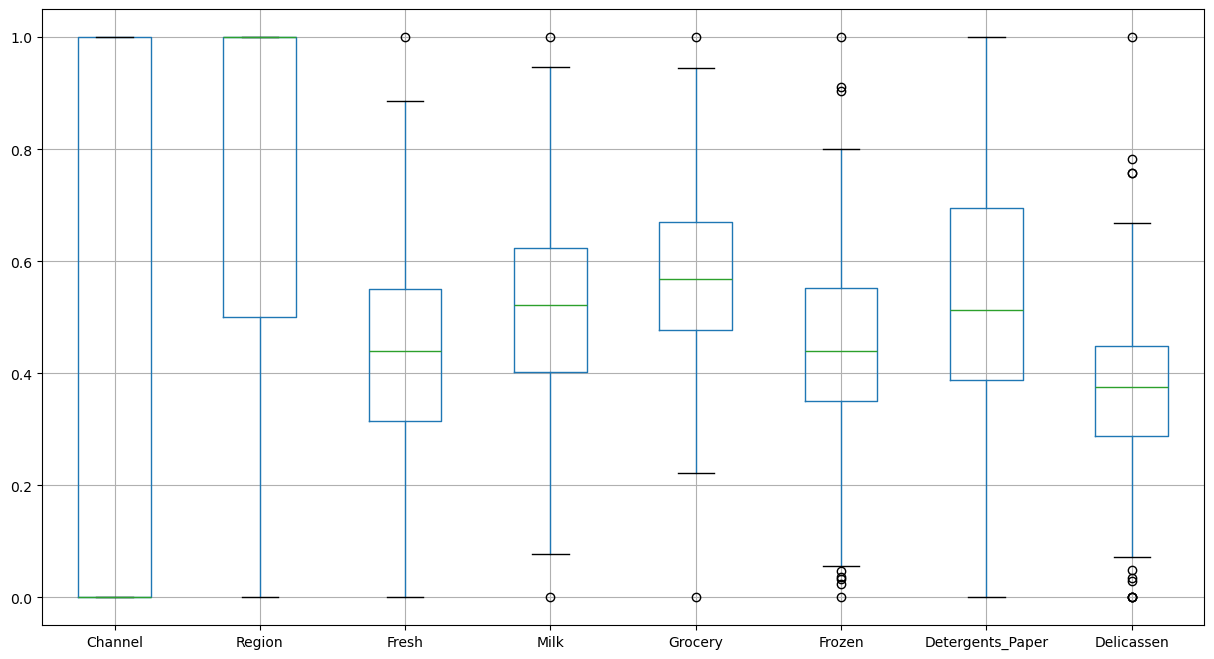

In [5]:
X.boxplot(figsize=(15,8));
plt.show()

In [6]:
k_range = list(range(2,11))
parameter_km = {'n_clusters': k_range}
pg = list(ParameterGrid(parameter_km))
inertias_km = []
silhouette_scores_km = []
for i in range(len(pg)):
    km = KMeans(pg[i]['n_clusters'],random_state=random_state)
    y_km = km.fit_predict(X)
    inertias_km.append(km.inertia_)
    silhouette_scores_km.append(silhouette_score(X,y_km)) 

In [7]:
k=4
km = KMeans(n_clusters=k, 
            random_state=random_state)
y_km = km.fit_predict(X)
print("Number of clusters = {}\t- Distortion = {:6.2f}\t- Silhouette score = {:4.2f}"\
    .format(k,inertias_km[k_range.index(k)],silhouette_scores_km[k_range.index(k)]))

Number of clusters = 4	- Distortion =  54.49	- Silhouette score = 0.49


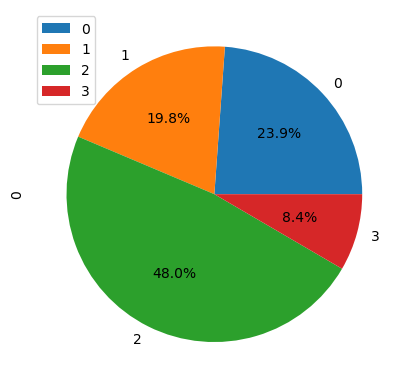

In [8]:
clust_sizes_km = np.unique(y_km,return_counts=True)
pd.DataFrame(clust_sizes_km[1]).plot.pie(y=0, autopct='%1.1f%%', );
plt.show()

## Agglomerative clustering

In [9]:
parameters = [
    {
        'n_clusters': k_range
        ,'linkage' : ['ward', 'complete', 'average', 'single']
    }
]

pg = list(ParameterGrid(parameters))

In [10]:
from sklearn.cluster import AgglomerativeClustering
results_ac = []
for i in range(len(pg)):
    ac = AgglomerativeClustering(n_clusters=pg[i]['n_clusters'], linkage=pg[i]['linkage'])
    y_ac = ac.fit_predict(X)
    results_ac.append([pg[i]['n_clusters'],pg[i]['linkage'],silhouette_score(X,y_ac)])

In [11]:
df_result_ac = pd.DataFrame(data=results_ac,columns=['n_clusters','linkage','silhouette_score'])
df_result_ac.sort_values(by='silhouette_score',ascending=False)

,n_clusters,linkage,silhouette_score
0,2,ward,0.499350
9,2,complete,0.499350
27,2,single,0.499350
18,2,average,0.499350
1,3,ward,0.498333
2,4,ward,0.493085
20,4,average,0.479507
11,4,complete,0.479507
21,5,average,0.475050
22,6,average,0.443867


In [12]:
print(df_result_ac.iloc[[2]])

   n_clusters linkage  silhouette_score
2           4    ward          0.493085


In [13]:
ac = AgglomerativeClustering(**(pg[2]))
y_ac = ac.fit_predict(X)

In [14]:
cluster_sizes_ac = np.unique(y_ac,return_counts=True)
cluster_sizes_ac

(array([0, 1, 2, 3]), array([212,  37,  86, 105]))

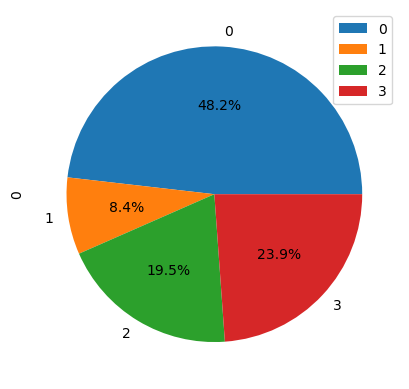

In [15]:
pd.DataFrame(cluster_sizes_ac[1]).plot.pie(y=0, autopct='%1.1f%%')
plt.show()

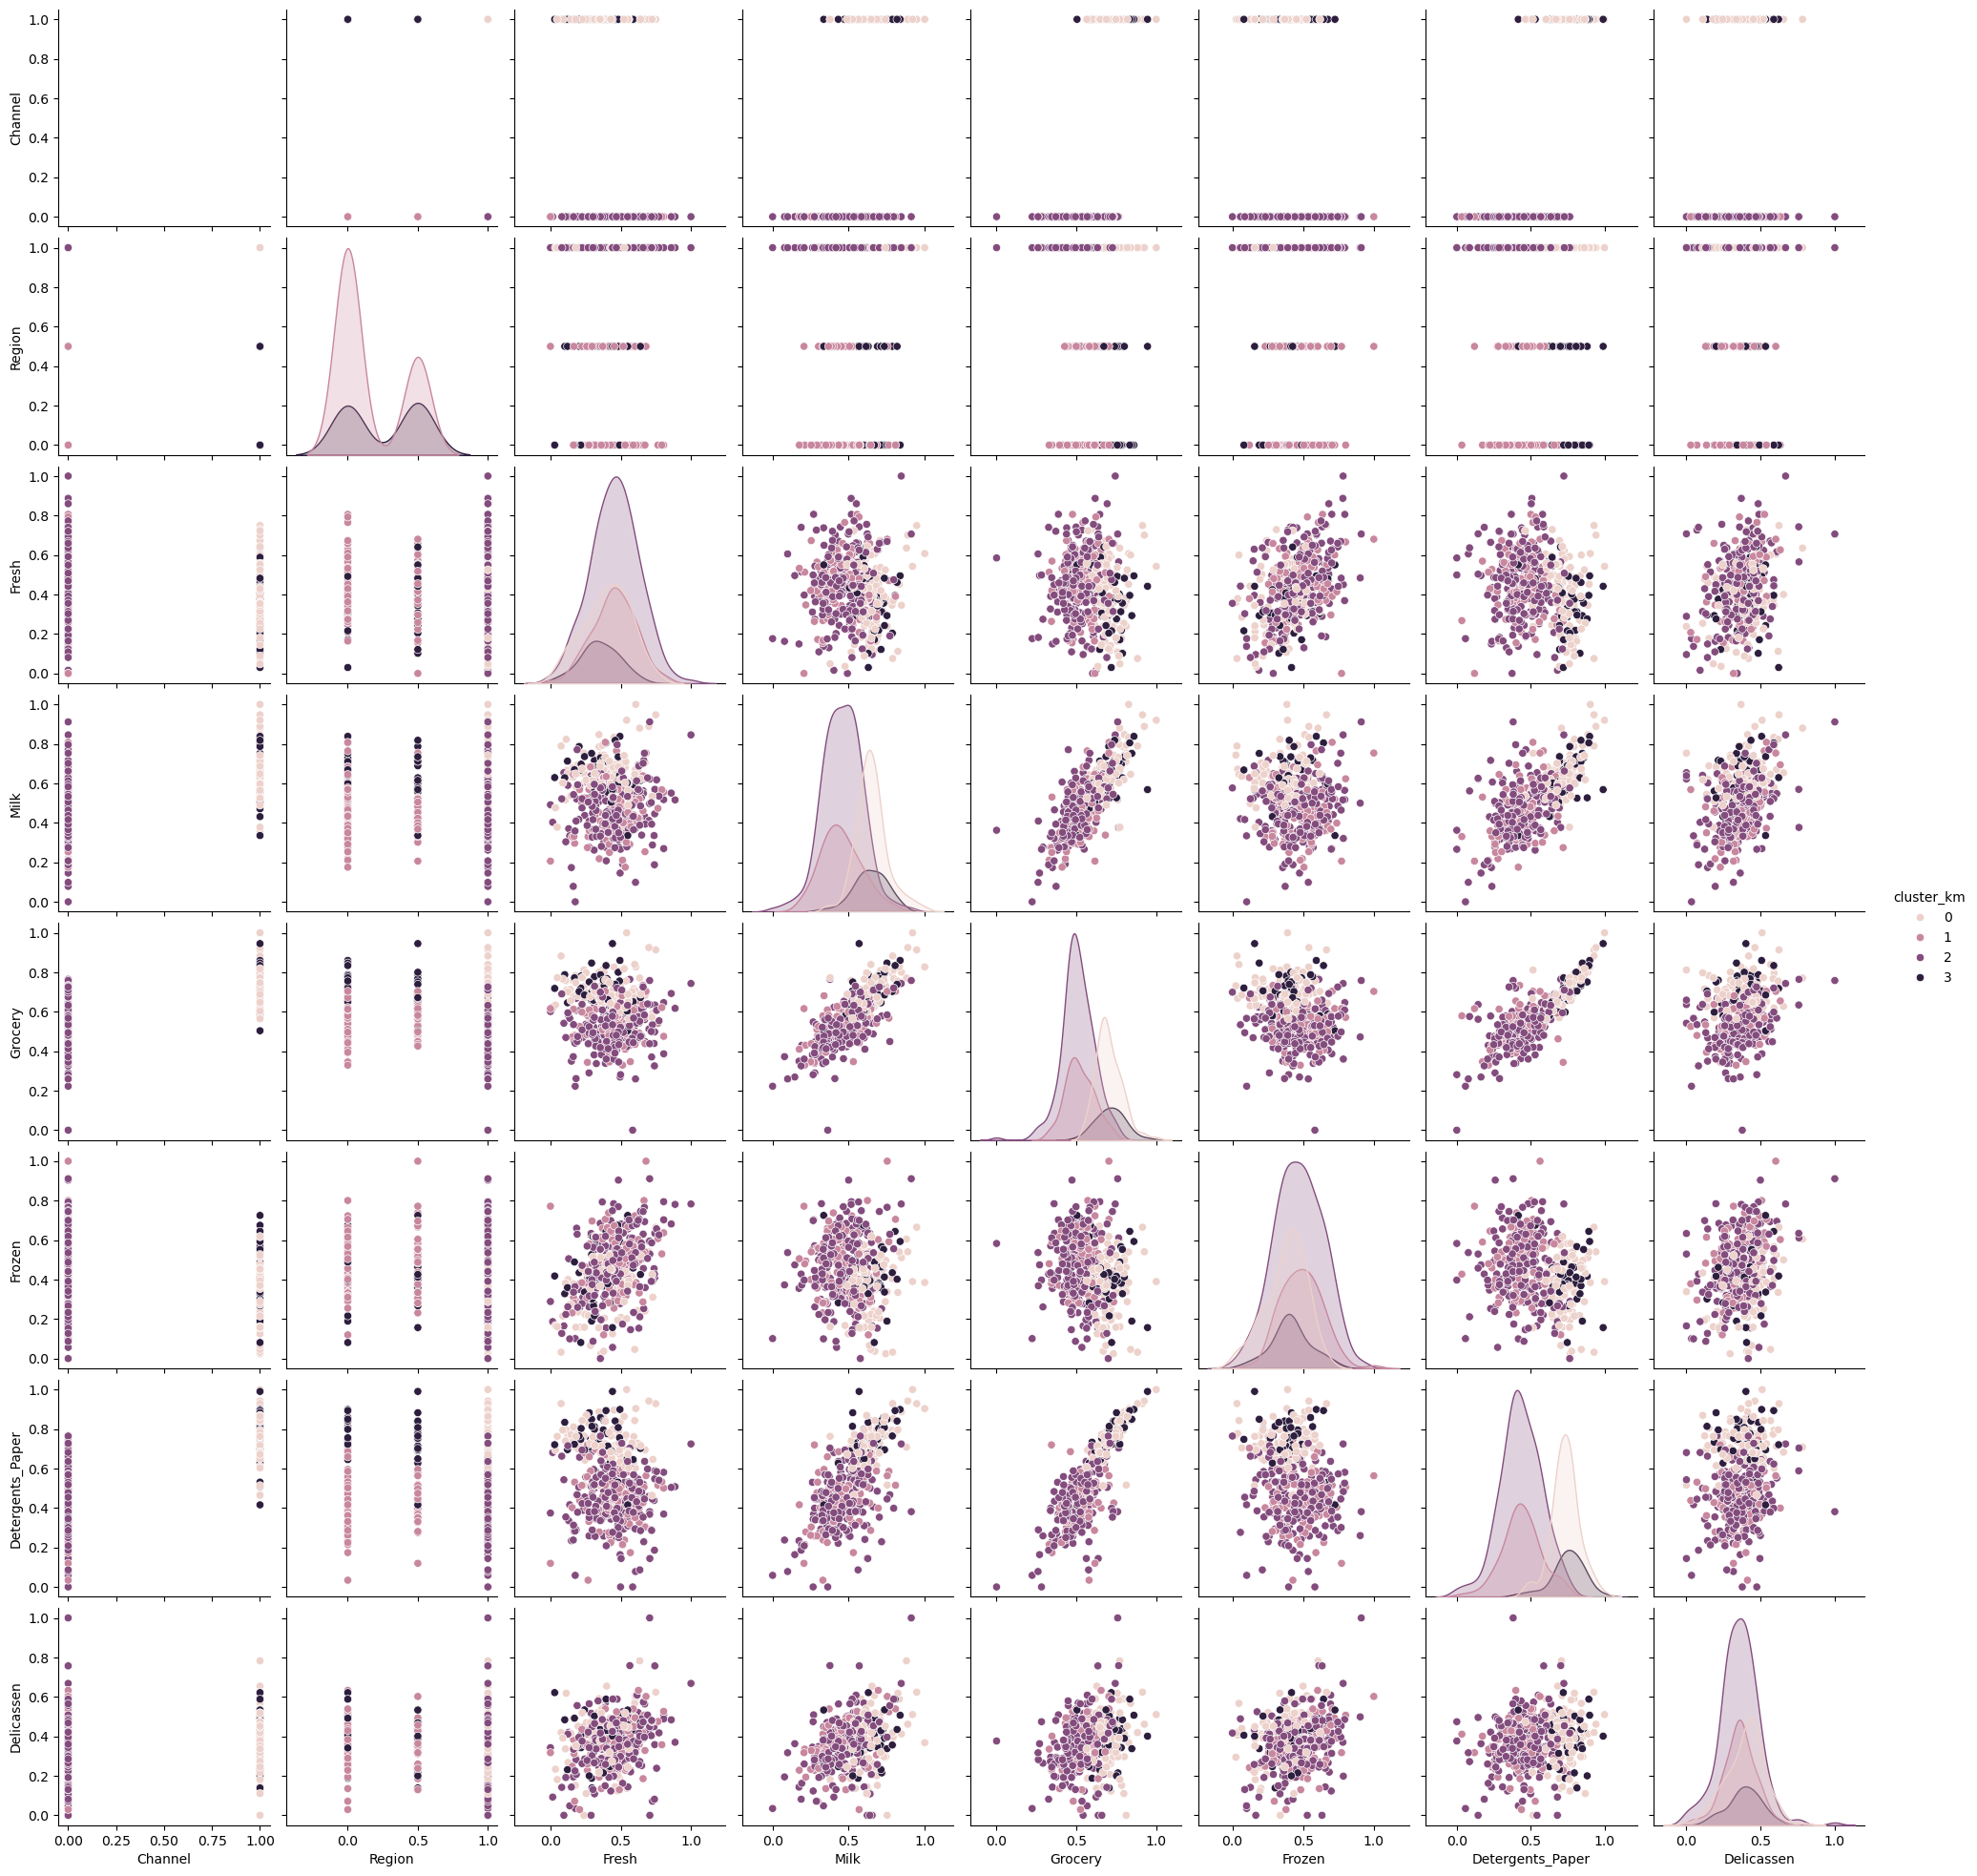

In [16]:
X['cluster_km']=y_km
sns.pairplot(data=X, hue='cluster_km');
plt.show()

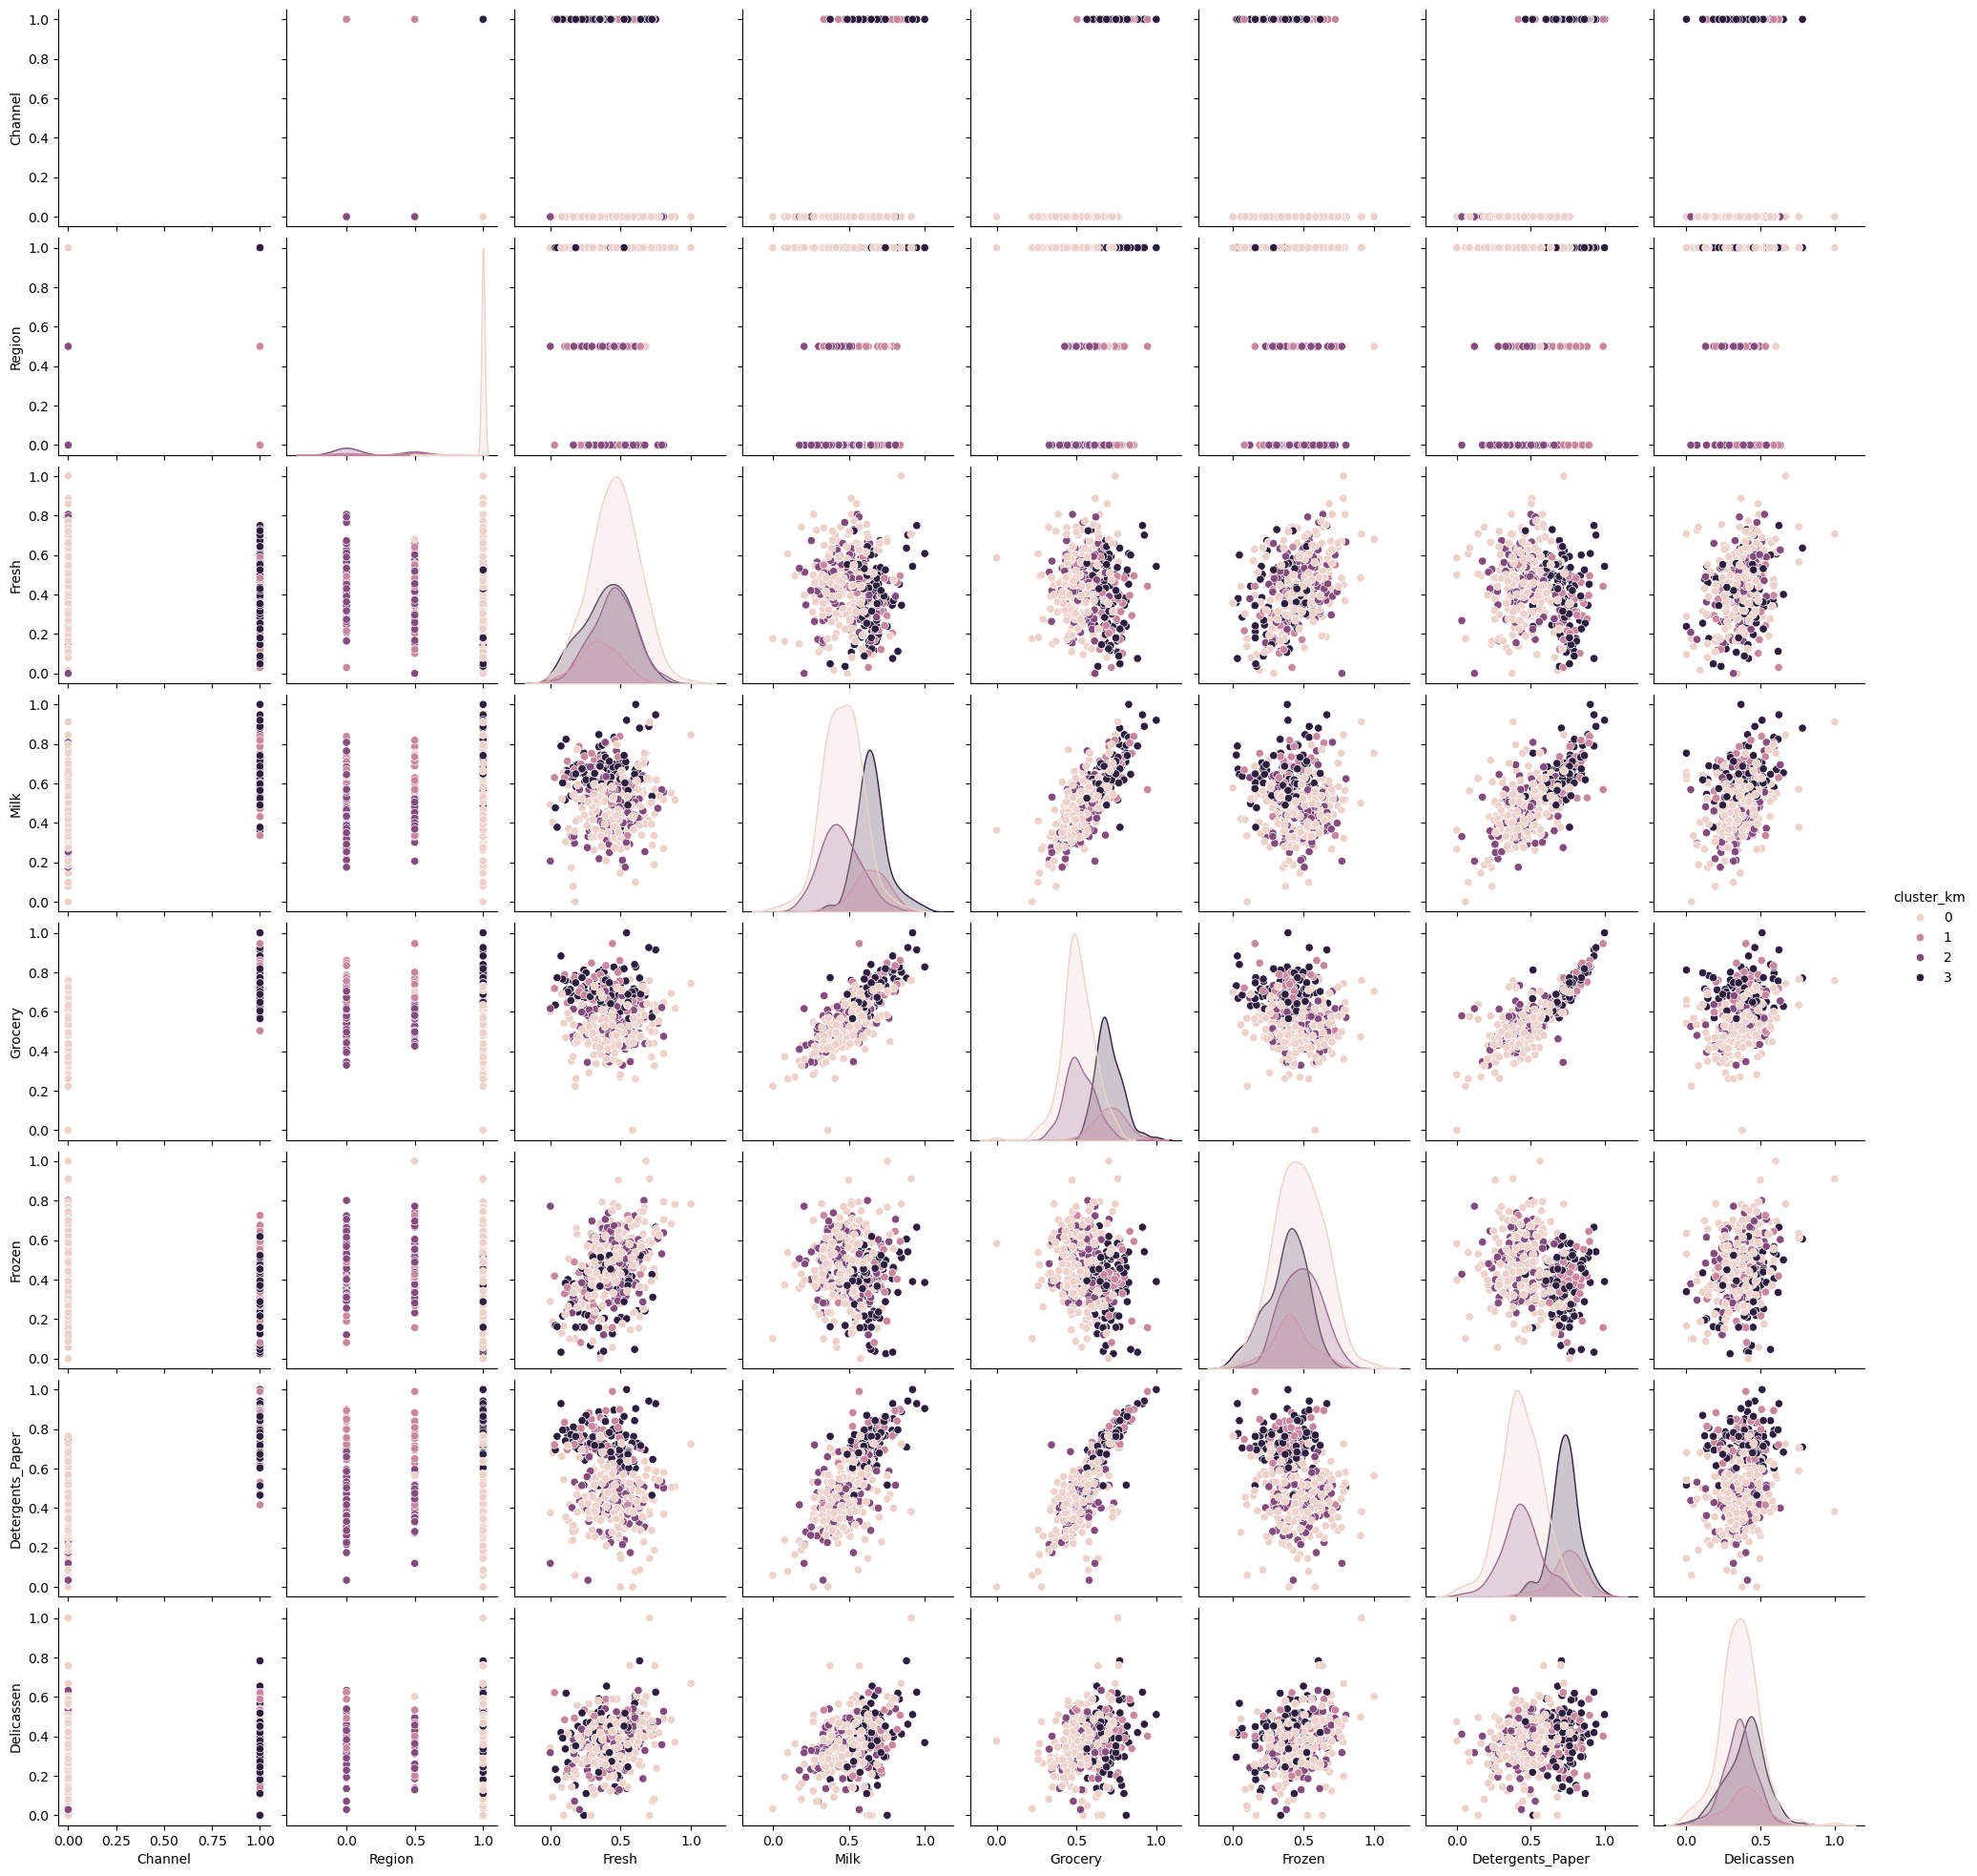

In [17]:
X['cluster_km']=y_ac
sns.pairplot(data=X, hue='cluster_km');
plt.show()

In [18]:
from sklearn.metrics import pair_confusion_matrix
pcm = pair_confusion_matrix(y_km,y_ac)
pcm / pcm.sum()

array([[0.66625595, 0.00218472],
       [0.00089045, 0.33066888]])

In [19]:
print("The percentage of match between the two clustering schemes is {:6.2f}%"\
    .format((pcm / pcm.sum()).diagonal().sum()*100))

The percentage of match between the two clustering schemes is  99.69%


In [20]:
from sklearn.cluster import DBSCAN
db = DBSCAN()
y_db = db.fit_predict(X)

In [21]:
print("Default parameters - Eps={} - Min_Samples={}".format(db.eps,db.min_samples))

Default parameters - Eps=0.5 - Min_Samples=5


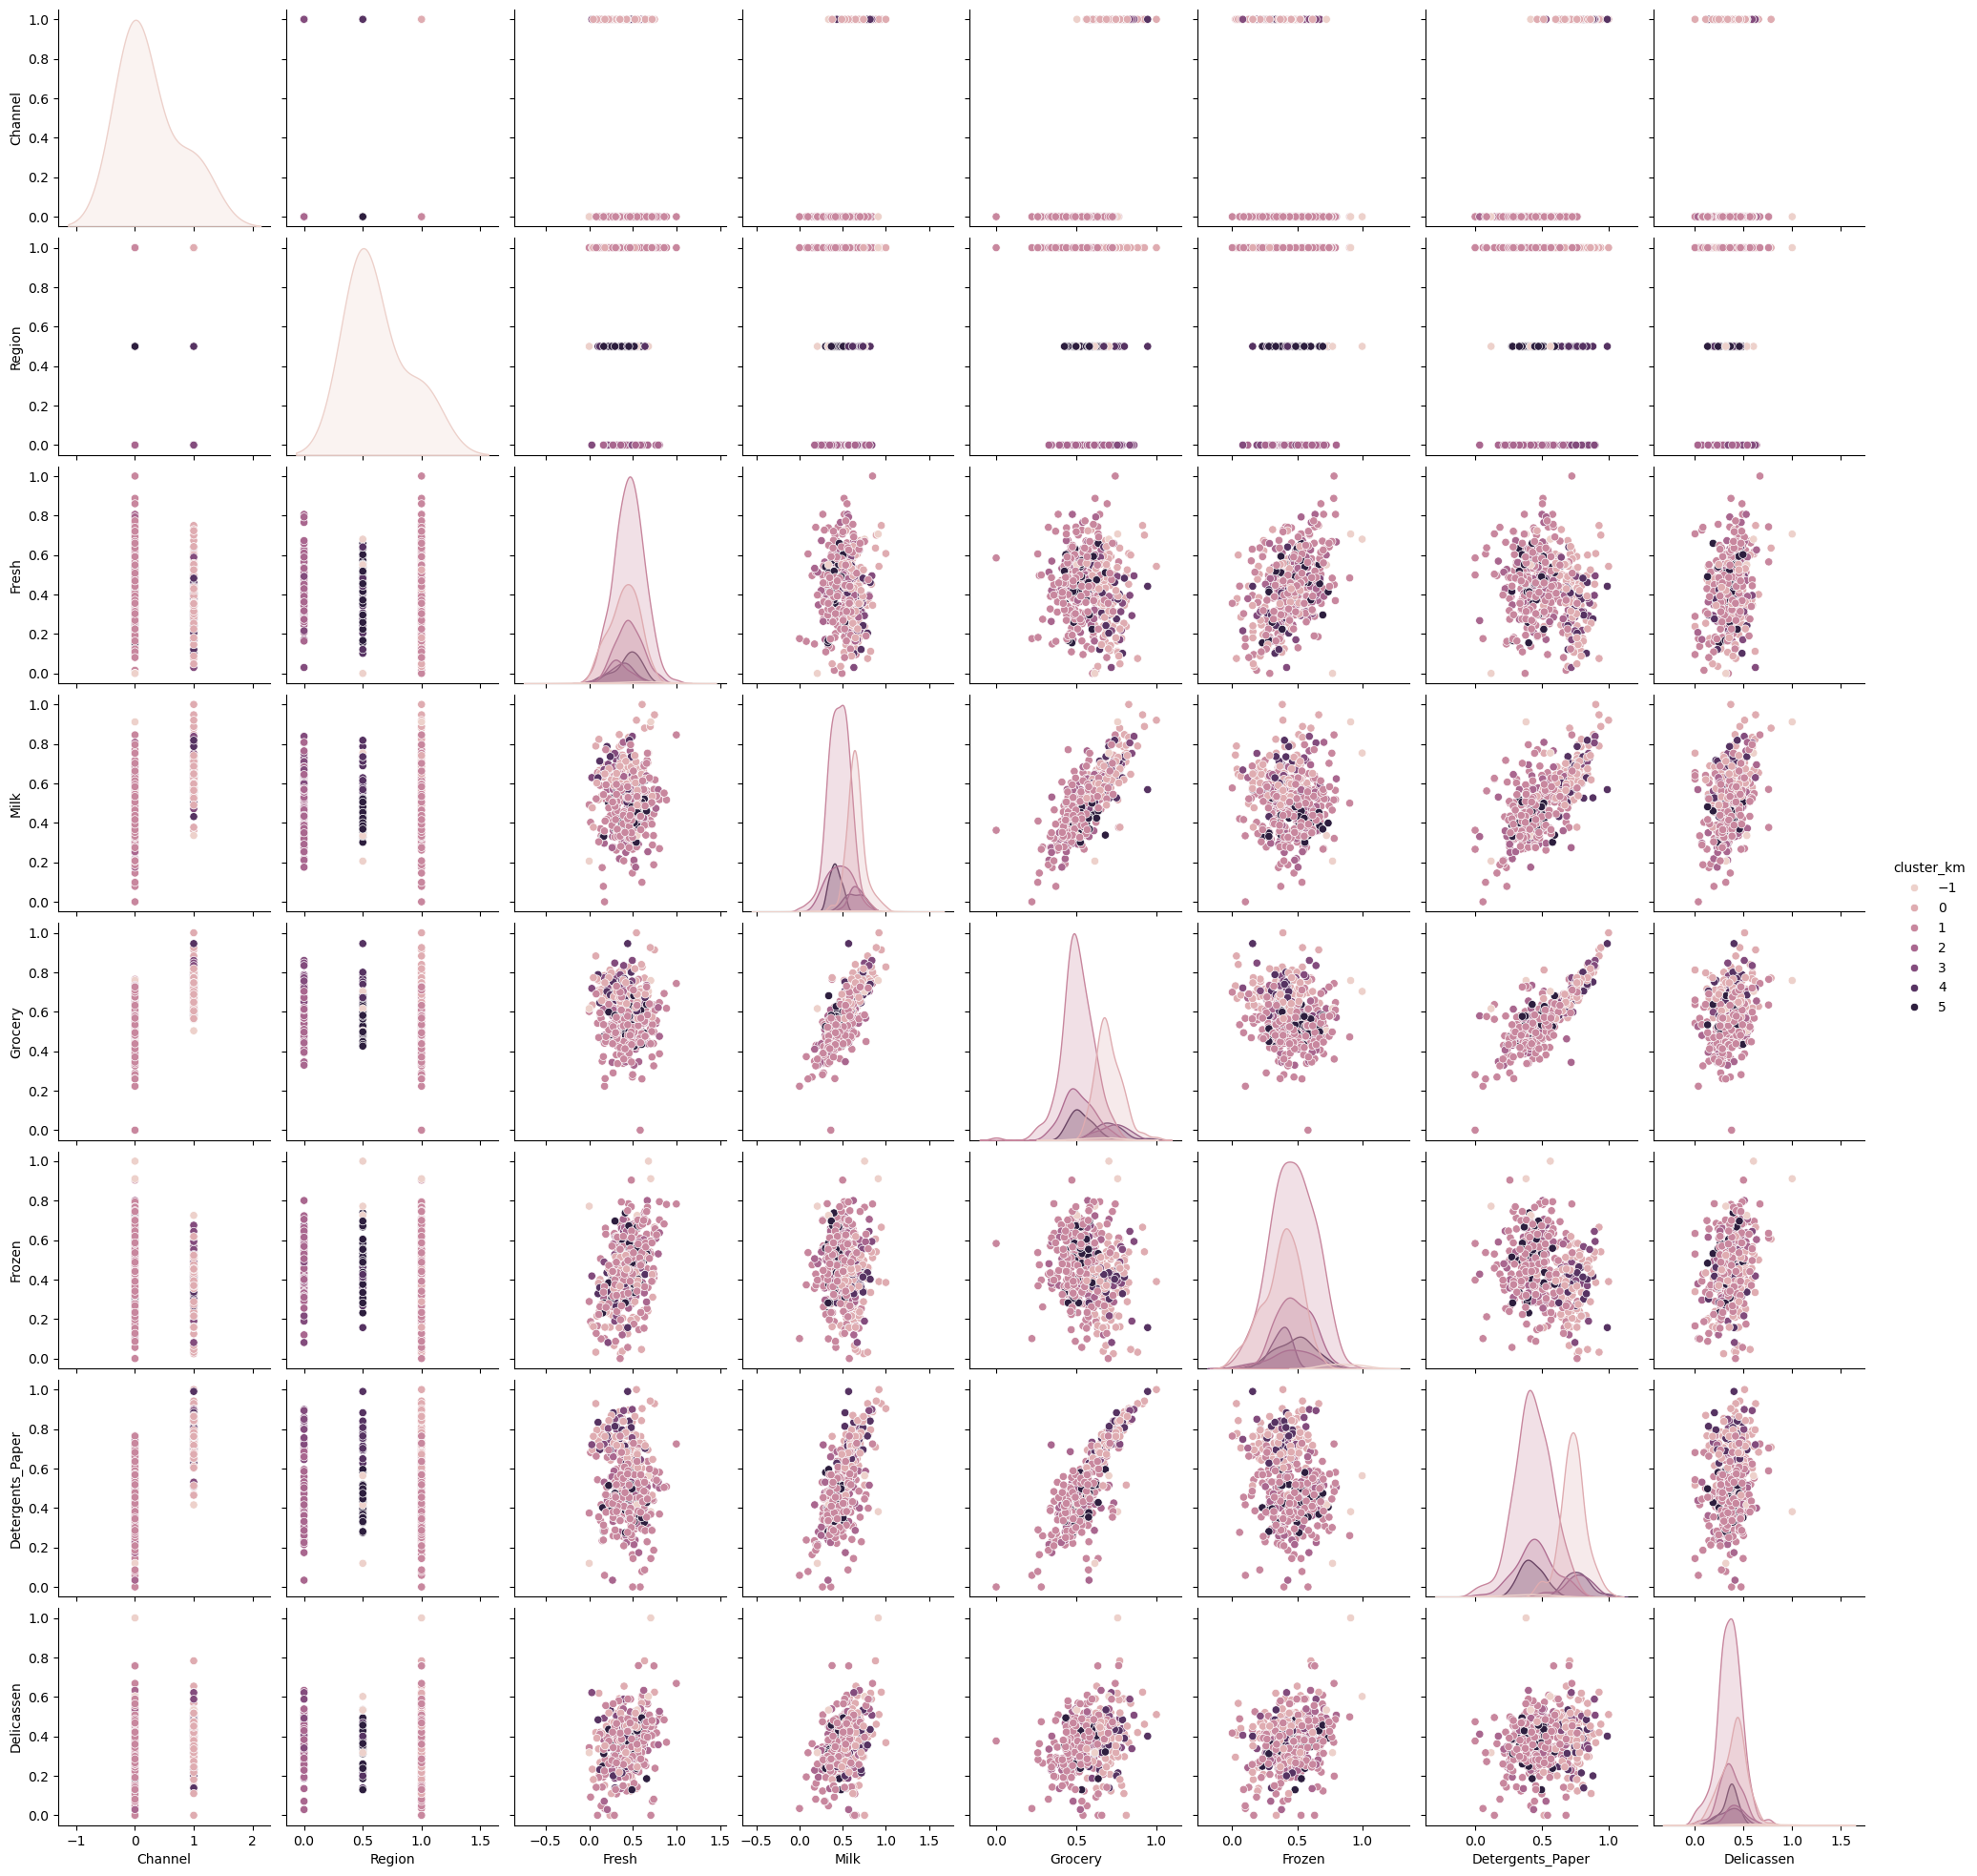

In [22]:
X['cluster_km']=y_db
sns.pairplot(data=X, hue='cluster_km');
plt.show()

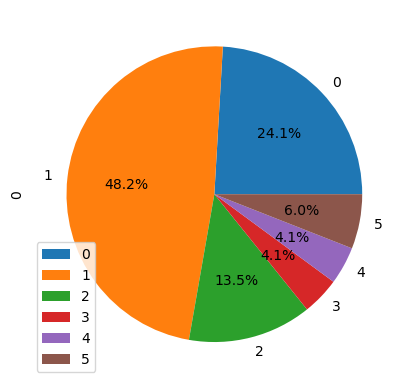

In [23]:
clust_sizes_db = np.unique(y_db[y_db!=-1],return_counts=True)
pd.DataFrame(clust_sizes_db[1]).plot.pie(y=0, autopct='%1.1f%%', );
plt.show()

In [24]:
X.drop('cluster_km', axis=1, inplace=True)

In [25]:
param_grid = {'eps': list(np.arange(0.001, 1, 0.005)), 'min_samples': list(range(2,10,1))}
params = list(ParameterGrid(param_grid))

In [26]:
dbscan_out = pd.DataFrame(columns =  ['eps','min_samples','n_clusters','silhouette', 'unclust%'])
for i in range(len(params)):
    db = DBSCAN(**(params[i]))
    y_db = db.fit_predict(X)
    cluster_labels_all = np.unique(y_db)
    cluster_labels = cluster_labels_all[cluster_labels_all != -1]
    n_clusters = len(cluster_labels)
    if n_clusters > 1 and n_clusters < len(X):
        X_cl = X.loc[y_db!=-1,:]
        y_db_cl = y_db[y_db!=-1]
        sil_score = silhouette_score(X_cl, y_db_cl)
        uncl_p = (1 - y_db_cl.shape[0]/y_db.shape[0]) * 100 # percentage of unclustered points
        dbscan_out.loc[len(dbscan_out)] = [params[i]['eps'], params[i]['min_samples'], n_clusters, sil_score, uncl_p]

In [27]:
sil_thr = 0.0  # visualize results only for combinations with silhouette above the threshold
unc_thr = 22 # visualize results only for combinations with unclustered% below the threshold
n_clu_max_thr = 5
dbscan_out[(dbscan_out['silhouette']>=sil_thr)\
         & (dbscan_out['unclust%']<=unc_thr)\
         & (dbscan_out['n_clusters']<=n_clu_max_thr)].sort_values(['silhouette','unclust%'],ascending=[False,True])

,eps,min_samples,n_clusters,silhouette,unclust%
652,0.506,2.0,4.0,0.529010,0.909091
653,0.506,3.0,4.0,0.529010,0.909091
654,0.506,4.0,4.0,0.529010,0.909091
655,0.506,5.0,4.0,0.529010,0.909091
656,0.506,6.0,4.0,0.529010,0.909091
...,...,...,...,...,...
1442,0.996,8.0,2.0,0.499350,0.000000
1443,0.996,9.0,2.0,0.499350,0.000000
235,0.241,9.0,5.0,0.393057,21.590909
243,0.246,9.0,5.0,0.393057,21.590909


In [28]:
dbscan_out[(dbscan_out['n_clusters']==4)].sort_values(['silhouette','unclust%'],ascending=[False,True])

,eps,min_samples,n_clusters,silhouette,unclust%
0,0.051,2.0,4.0,0.809127,98.181818
55,0.131,5.0,4.0,0.577401,75.681818
114,0.166,8.0,4.0,0.564877,59.090909
123,0.171,9.0,4.0,0.556483,57.500000
122,0.171,8.0,4.0,0.554163,55.454545
131,0.176,9.0,4.0,0.552283,54.772727
130,0.176,8.0,4.0,0.551633,53.181818
139,0.181,9.0,4.0,0.549653,53.863636
138,0.181,8.0,4.0,0.549119,51.590909
120,0.171,6.0,4.0,0.546914,49.545455


In [29]:
best = {'eps':0.506, 'min_samples': 2}

db = DBSCAN(**best)
y_db = db.fit_predict(X)

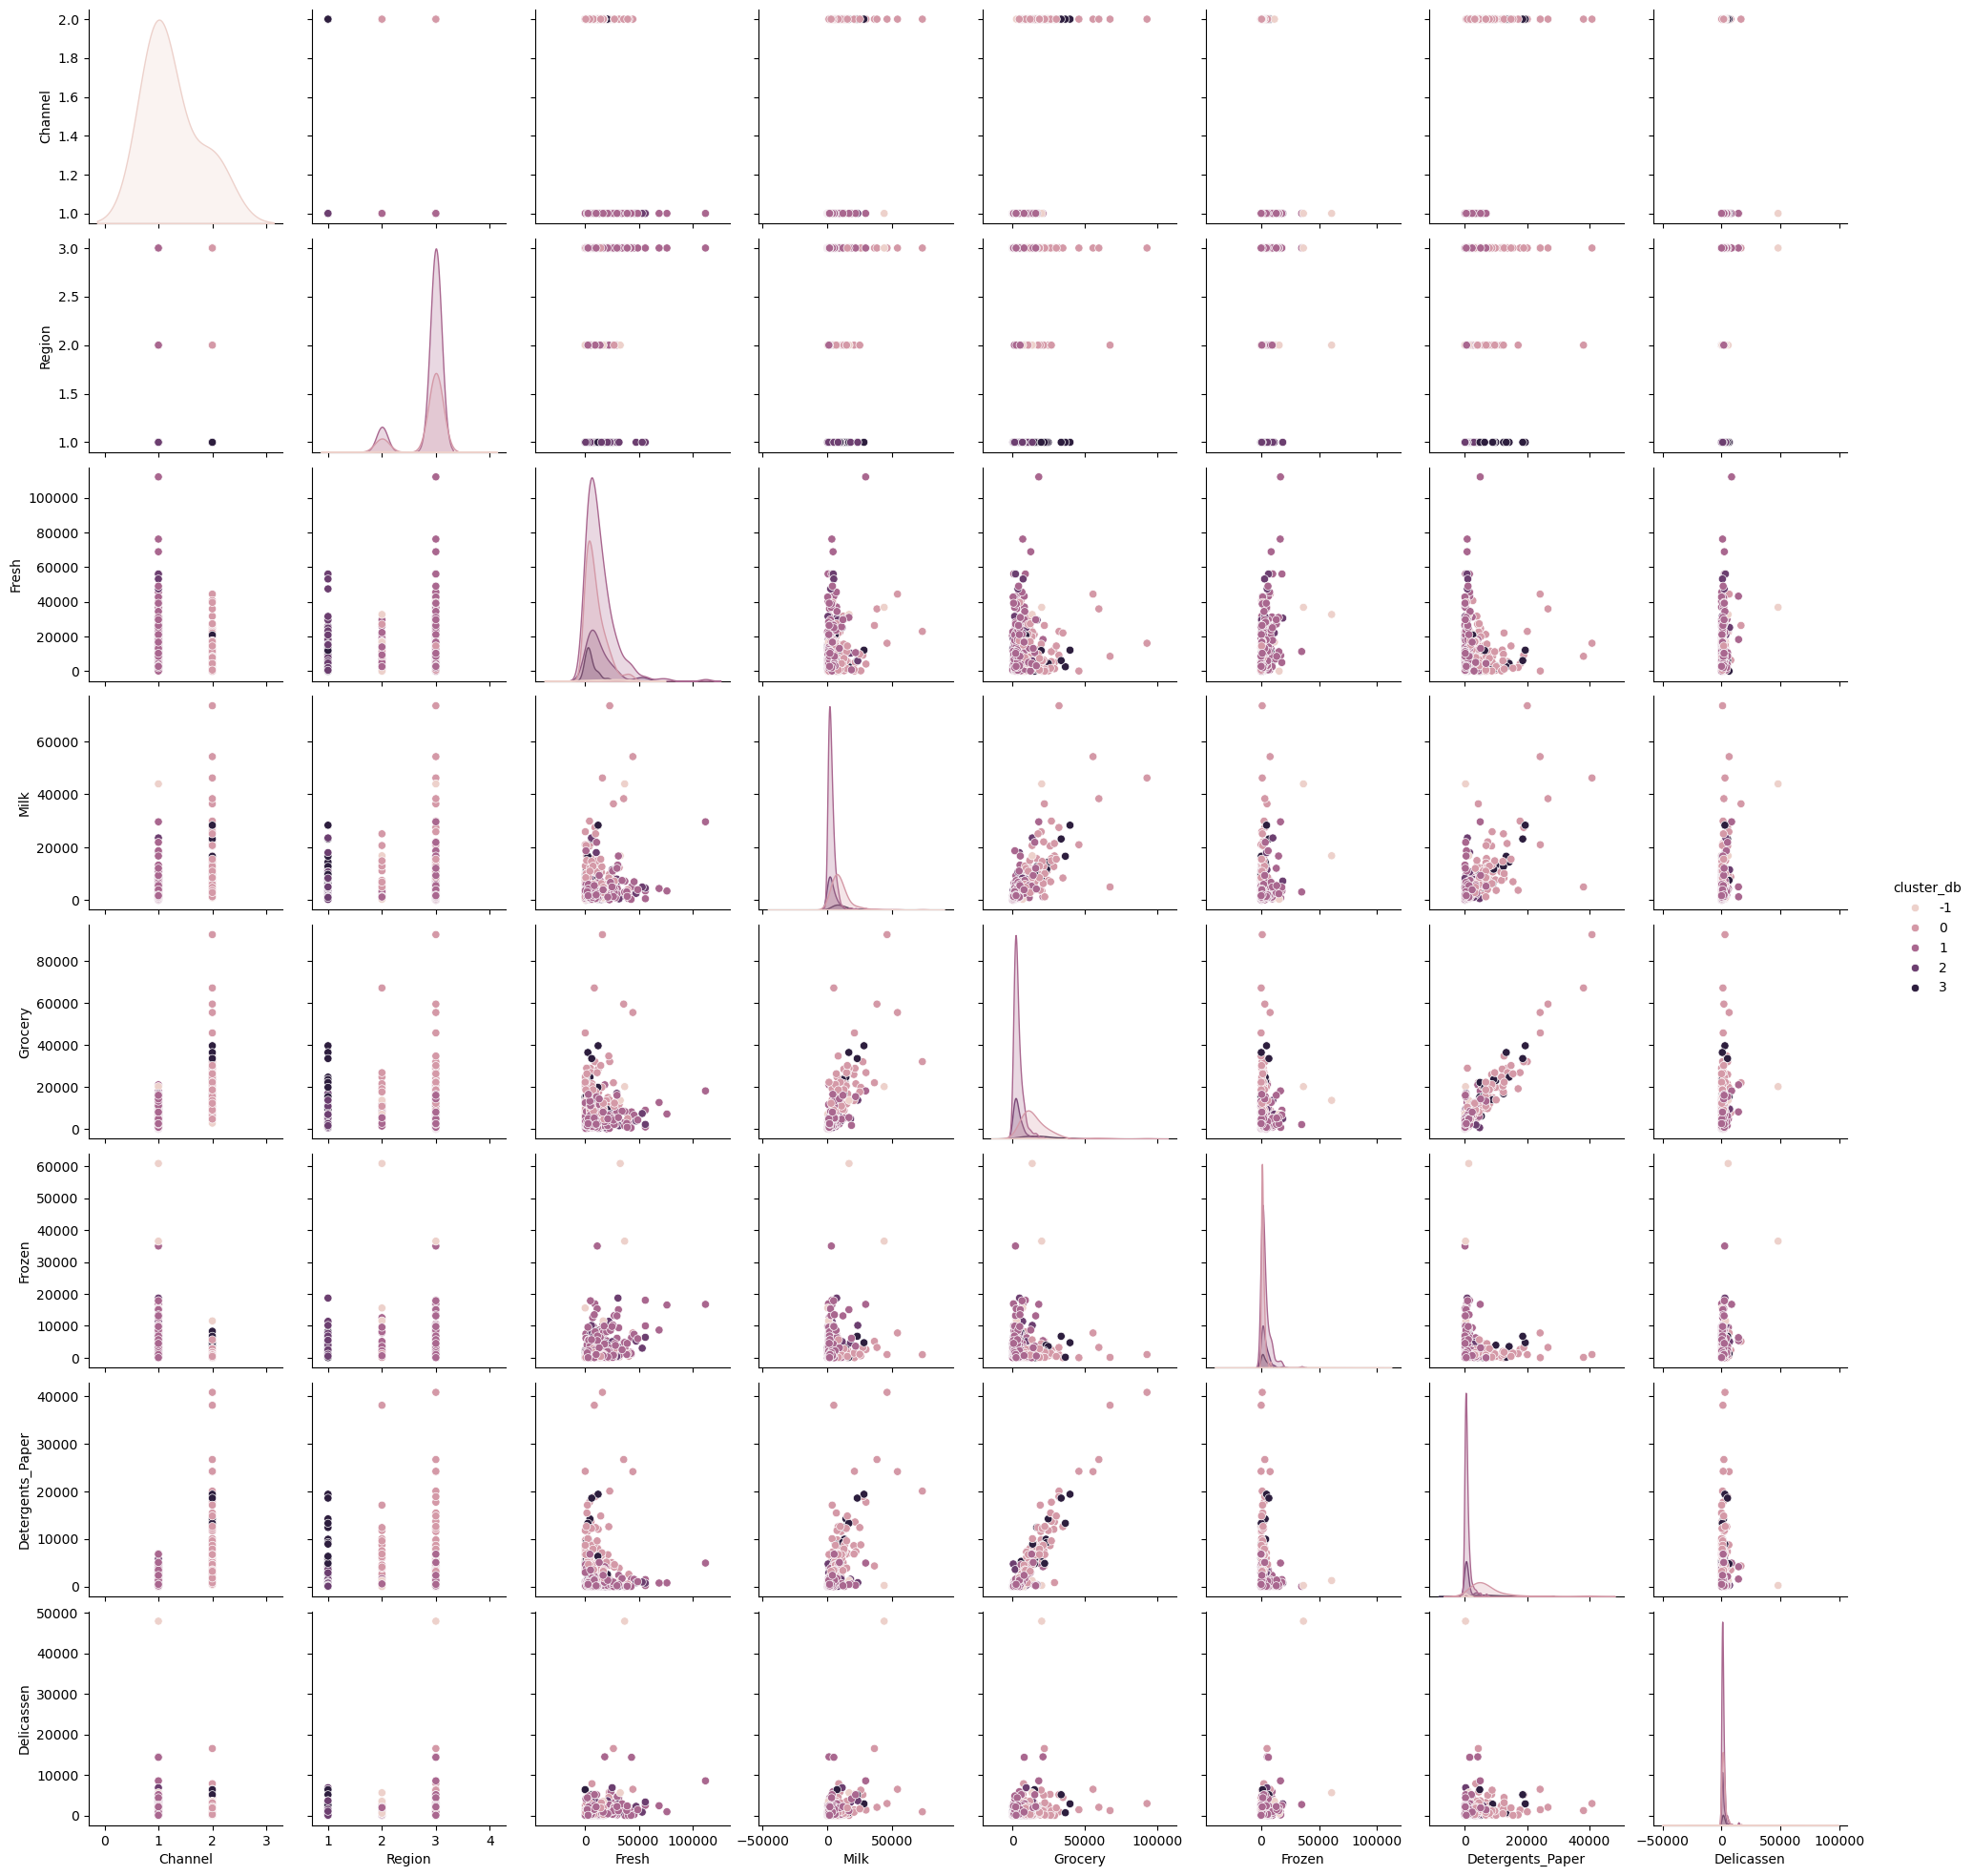

In [30]:
X0['cluster_db']=y_db
sns.pairplot(data=X0, hue='cluster_db');
plt.show()

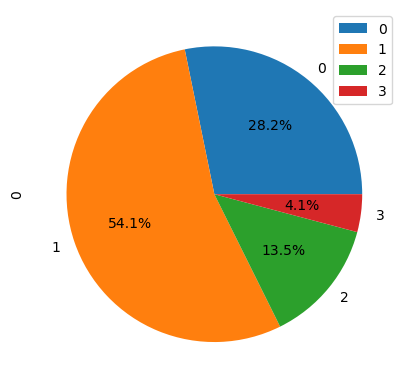

In [31]:
clust_sizes_db = np.unique(y_db[y_db!=-1],return_counts=True)
pd.DataFrame(clust_sizes_db[1]).plot.pie(y=0
                                         , autopct='%1.1f%%'
                                         );
plt.show()